# Where do the oldest residents live?

**Business question:** The need for hands-on help rises sharply with age. Which areas have the most people 75 and older, and 85 and older? Does looking at the oldest residents change which areas I should focus on?

**Why it matters:** If the oldest residents cluster in different places than older adults in general, my hands-on care outreach should go there. If they live in the same places, age adds nothing new and I can leave it out of the final scorecard.

**Data:** `data/census_by_zip.csv`, built by notebook 00 from the Census American Community Survey (ACS) 2020-2024.

**How to run:** Run the cells top to bottom. No Census key needed.

In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 200)

DATA = "../data/census_by_zip.csv"
if not os.path.exists(DATA):
    raise FileNotFoundError("Run notebook 00_get_data first. It creates data/census_by_zip.csv.")
table = pd.read_csv(DATA, dtype={"zip": str}).set_index("zip")
print(table.shape[0], "ZIP code areas loaded")

24 ZIP code areas loaded


## 1. Count the oldest residents in each area

- **share_75plus**: of the people 65 and older in an area, the share who are 75 or older.
- **rank_...**: the area's place when sorted by that age group (1 = most people).
- **in_nursing_homes_65plus**: people 65+ who live in group quarters, which for this age group mostly means nursing homes. The Census age counts include them, but they are not home-care clients.

In [2]:
t = table[["area"]].copy()
t["age_65plus"] = table["residents_65plus"]
t["age_75plus"] = table["residents_75plus"]
t["age_85plus"] = table["residents_85plus"]
t["age_75_to_84"] = t["age_75plus"] - t["age_85plus"]
t["share_75plus"] = t["age_75plus"] / t["age_65plus"]
t["in_nursing_homes_65plus"] = table["group_quarters_65plus"]
t["share_in_nursing_homes"] = t["in_nursing_homes_65plus"] / t["age_65plus"]
for group in ["65plus", "75plus", "85plus"]:
    t[f"rank_{group}"] = t[f"age_{group}"].rank(ascending=False, method="min").astype(int)
t = t.sort_values("age_75plus", ascending=False)
t.round(2)

,area,age_65plus,age_75plus,age_85plus,age_75_to_84,share_75plus,in_nursing_homes_65plus,share_in_nursing_homes,rank_65plus,rank_75plus,rank_85plus
zip,,,,,,,,,,,
94501,"Alameda, main island",10926,4277,1908,2369,0.39,713,0.07,1,1,1
94611,"Oakland, Montclair / Piedmont",8708,4040,991,3049,0.46,215,0.02,2,2,2
94605,"Oakland, East Oakland hills",7019,2714,854,1860,0.39,64,0.01,3,3,4
94601,"Oakland, Fruitvale",6660,2609,878,1731,0.39,360,0.05,4,4,3
94610,"Oakland, Grand Lake",5725,2472,837,1635,0.43,192,0.03,6,5,5
94606,"Oakland, San Antonio / Eastlake",5512,2318,759,1559,0.42,244,0.04,7,6,6
94602,"Oakland, Glenview / Dimond",5939,2298,639,1659,0.39,146,0.02,5,7,8
94619,"Oakland, Laurel / Redwood Heights",4408,1812,281,1531,0.41,140,0.03,8,8,19
94618,"Oakland, Rockridge",3849,1721,321,1400,0.45,13,0.00,10,9,16


## 2. Does age change the ranking?

The overlap score compares two rankings. A score of 1 means the areas come out in exactly the same order. A score near 0 means the two rankings have nothing in common.

In [3]:
overall = t["age_75plus"].sum() / t["age_65plus"].sum()
overlap_75 = t["rank_65plus"].corr(t["rank_75plus"])
overlap_85 = t["rank_65plus"].corr(t["rank_85plus"])
print(f"Across all areas, {overall:.0%} of people 65+ are 75 or older.")
print(f"Overlap between the 65+ ranking and the 75+ ranking: {overlap_75:.2f}")
print(f"Overlap between the 65+ ranking and the 85+ ranking: {overlap_85:.2f}\n")

print("Top 5 areas for people 85 and older:")
for z, row in t.sort_values("age_85plus", ascending=False).head(5).iterrows():
    print(f"   {z}  {row['area']}: {row['age_85plus']:,.0f}")

jump = t["rank_65plus"] - t["rank_85plus"]      # positive = ranks higher among the 85+
print("\nAreas that rank much higher for 85+ than for 65+ (5 places or more):")
for z in jump[jump >= 5].sort_values(ascending=False).index:
    print(f"   {z}  {t.loc[z, 'area']}: place {t.loc[z, 'rank_65plus']} for 65+, place {t.loc[z, 'rank_85plus']} for 85+")
print("\nAreas that rank much lower for 85+ than for 65+ (5 places or more):")
for z in jump[jump <= -5].sort_values().index:
    print(f"   {z}  {t.loc[z, 'area']}: place {t.loc[z, 'rank_65plus']} for 65+, place {t.loc[z, 'rank_85plus']} for 85+")

print("\nAreas where 4% or more of people 65+ live in nursing homes or other group quarters:")
for z, row in t[t["share_in_nursing_homes"] >= 0.04].sort_values("share_in_nursing_homes", ascending=False).iterrows():
    print(f"   {z}  {row['area']}: {row['in_nursing_homes_65plus']:,.0f} people ({row['share_in_nursing_homes']:.0%})")

Across all areas, 41% of people 65+ are 75 or older.
Overlap between the 65+ ranking and the 75+ ranking: 0.98
Overlap between the 65+ ranking and the 85+ ranking: 0.83

Top 5 areas for people 85 and older:
   94501  Alameda, main island: 1,908
   94611  Oakland, Montclair / Piedmont: 991
   94601  Oakland, Fruitvale: 878
   94605  Oakland, East Oakland hills: 854
   94610  Oakland, Grand Lake: 837

Areas that rank much higher for 85+ than for 65+ (5 places or more):
   94612  Oakland, downtown: place 15 for 65+, place 7 for 85+
   94609  Oakland, Temescal: place 21 for 65+, place 14 for 85+
   94702  Berkeley, west: place 17 for 65+, place 12 for 85+
   94502  Alameda, Bay Farm Island: place 20 for 65+, place 15 for 85+

Areas that rank much lower for 85+ than for 65+ (5 places or more):
   94619  Oakland, Laurel / Redwood Heights: place 8 for 65+, place 19 for 85+
   94618  Oakland, Rockridge: place 10 for 65+, place 16 for 85+
   94708  Berkeley hills: place 16 for 65+, place 22 for

## 3. Chart: the ten areas with the most residents 75 and older

Each bar is the number of people 75 and older. The dark part of the bar is people 85 and older.

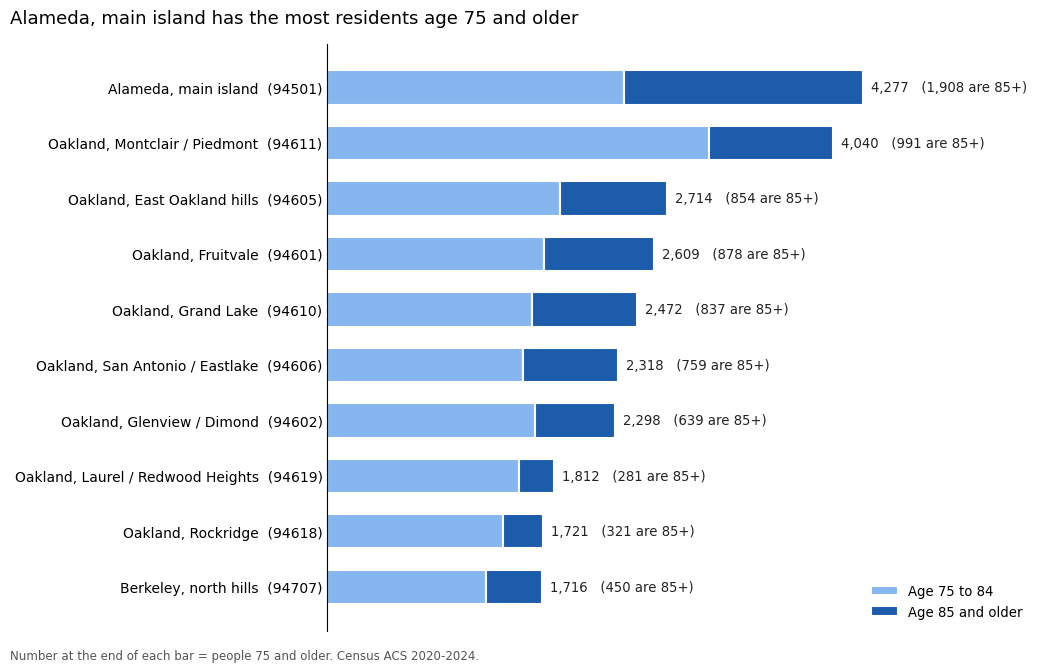

In [4]:
OUT = "../outputs"
os.makedirs(OUT, exist_ok=True)

show = t.head(10)
ypos = list(range(len(show)))[::-1]   # first row at the top
labels = [f"{row['area']}  ({z})" for z, row in show.iterrows()]
LIGHT, DARK = "#86b6ef", "#1c5cab"    # one color, light to dark: older = darker

fig, ax = plt.subplots(figsize=(10.5, 0.45 * len(show) + 2.2))
ax.barh(ypos, show["age_75_to_84"], color=LIGHT, height=0.62, edgecolor="white", linewidth=1.5, label="Age 75 to 84")
ax.barh(ypos, show["age_85plus"], left=show["age_75_to_84"], color=DARK, height=0.62,
        edgecolor="white", linewidth=1.5, label="Age 85 and older")
longest = show["age_75plus"].max()
for y, (z, row) in zip(ypos, show.iterrows()):
    ax.text(row["age_75plus"] + longest * 0.015, y,
            f"{row['age_75plus']:,.0f}   ({row['age_85plus']:,.0f} are 85+)", va="center", fontsize=9.5, color="#222222")
ax.set_yticks(ypos)
ax.set_yticklabels(labels, fontsize=10)
ax.set_xlim(0, longest * 1.32)
ax.set_xticks([])
ax.tick_params(axis="y", length=0)
for side in ["top", "right", "bottom"]:
    ax.spines[side].set_visible(False)
ax.legend(loc="lower right", frameon=False, fontsize=9.5)
top = show.index[0]
fig.suptitle(f"{show.loc[top, 'area']} has the most residents age 75 and older", x=0.01, ha="left", fontsize=13)
fig.text(0.01, 0.01, "Number at the end of each bar = people 75 and older. Census ACS 2020-2024.", fontsize=8.5, color="#555555")
plt.tight_layout(rect=(0, 0.03, 1, 1))
fig.savefig(f"{OUT}/oldest_residents.png", dpi=150)
t.round(3).to_csv(f"{OUT}/oldest_residents.csv")
plt.show()

## 4. What I decided

- **Does age change where I focus?** No. Ranking the areas by people 75+ gives almost the same order as ranking by people 65+.
- **Areas to note for the oldest residents (85+):** Alameda's main island, which has nearly twice as many as any other area even after allowing for nursing homes, and downtown Oakland.
- **Keep age in the final scorecard, or leave it out?** Leave it out. It repeats what the 65+ count already says.

### Limits to remember
- Age is not the same as need. Notebook 02 measures difficulty directly, which is closer to who needs hands-on help.
- The age counts include people living in nursing homes, who are not home-care clients. Section 2 lists the areas where that matters most.
- ZIP-code estimates are survey-based. The 85+ counts are small numbers, so treat close ranks as ties.